# Álgebra lineal y geometría en R^3

 NumPy es una librería de Python especializada en matemáticas y permite analizar un gran volumen de datos.

arrays: un tipo de objeto que permite representar colecciones de datos de un mismo tipo en varias dimensiones 

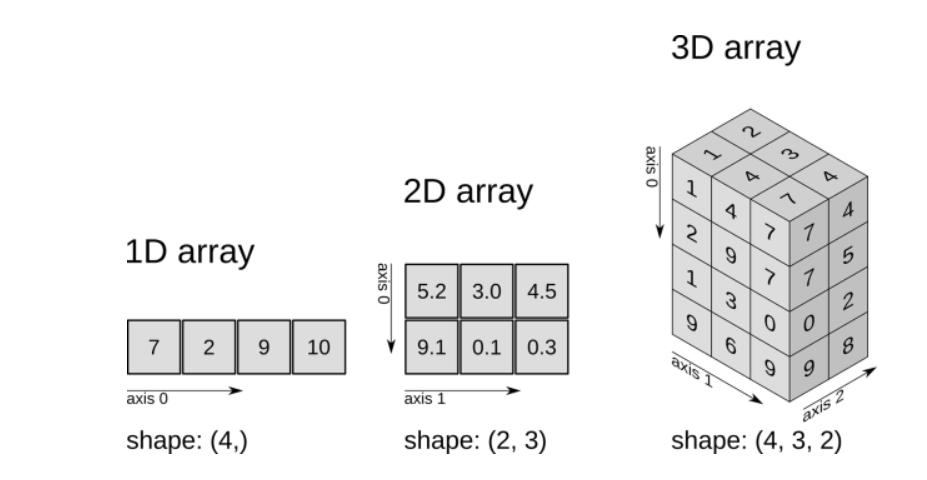
Un array de dimensión 1 es un vector
Un array de dimensión 2 es una matriz

matplotlib es una librería de Python que permite crear gráficos en dimensión dos (histogramas, diagramas de caja o de dispersión...)
Toolkits ofrece una colección de funciones que permiten funciones específicas que amplían la capacidad de Matplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Operaciones con vectores. Representación gráfica

In [2]:
#Creamos un vector: es igual que declarar una matriz de una sola fila
v=np.array([3,5,-1])
len(v)   #permite calcular la longitud del vector

3

In [3]:
# Consideramos dos vectores de R^2
v1 = np.array([ 3, -1 ])
v2 = np.array([ 2,  4 ])

v3 = v1 + v2
v3

array([5, 3])

In [4]:
#Producto de un escalar por un vector
(-3)*v

array([ -9, -15,   3])

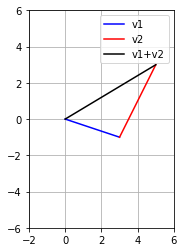

In [5]:
# y  representamos v1 y v2 gráficamente
plt.plot([0, v1[0]],[0, v1[1]],'b',label='v1')
plt.plot([0, v2[0]]+v1[0],[0, v2[1]]+v1[1],'r',label='v2')
plt.plot([0, v3[0]],[0, v3[1]],'k',label='v1+v2')

plt.legend()
plt.axis('square')
plt.axis((-2, 6, -6, 6 ))
plt.grid()
plt.show()

In [6]:
#¿Y cómo representamos un vector de R^3?

v3 = [ 4, -3, 2 ]
v3


[4, -3, 2]

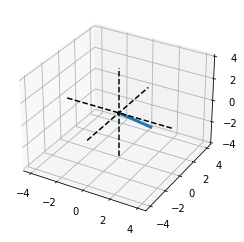

In [7]:
# plot the 3D vector
fig = plt.figure(figsize=plt.figaspect(1))
ax = plt.axes(None, projection='3d')
ax.plot([0, v3[0]],[0, v3[1]],[0, v3[2]],linewidth=3)

# make the plot look nicer
ax.plot([0, 0],[0, 0],[-4, 4],'k--')
ax.plot([0, 0],[-4, 4],[0, 0],'k--')
ax.plot([-4, 4],[0, 0],[0, 0],'k--')
plt.show()

# Producto escalar y norma

In [8]:
def ProdEscalar(x,y):
    if len(x)==len(y):
        suma=0
        for i in range (0, len(x)):
            suma=suma+x[i]*y[i]
        return suma
    else:
        print("No es posible sumar dos vectores de diferente dimensión")       

In [9]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
ProdEscalar(x,y)

17

In [11]:
#Y otra forma de implementar el producto escalar
ProdEscalar2 =  sum( np.multiply(x,y)) 
ProdEscalar2

17

In [21]:
x=np.array([1,2,-3])
y=np.array([3,4,-2,1])
ProdEscalar(x,y)

No es posible sumar dos vectores de diferente dimensión


La norma de un vector se puede calcular utilizando la función numpy.linalg.norm() o bien definiendo una función que calcule la raíz cuadrada del producto escalar de un vector por sí mismo

In [22]:
x=np.array([1,2,-3])
np.linalg.norm(x)

3.7416573867739413

In [33]:
import math
math.sqrt(ProdEscalar(x,x))

3.7416573867739413

# Ángulo entre dos vectores y distancia euclídea entre dos puntos

In [60]:
def angleRad(x,y):
    if len(x)==len(y):
        angle=math.acos(ProdEscalar(x,y)/(np.linalg.norm(x)*np.linalg.norm(y)))
        return angle
    else:
        print("Error: los vectores tienen diferente dimensión")
        

In [63]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
angleRad(x,y)

0.5666652401762405

In [67]:
# Y si queremos el ángulo expresado en grados 
def angleGrad(x,y):
    if len(x)==len(y):
        angle=math.acos(ProdEscalar(x,y)/(np.linalg.norm(x)*np.linalg.norm(y)))
        return angle/math.pi*180
    else:
        print("Error: los vectores tienen diferente dimensión")

In [68]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
angleGrad(x,y)

32.467526658865715

In [42]:
def distancia(x,y):
    if len(x)==len(y):
        dist=np.linalg.norm(x-y)
        return(dist)
    else:
        print("Error: los dos puntos pertenecen a espacios distintos")

In [53]:
x=np.array([1,2,-3])
y=np.array([3,4,0,1])
distancia(x,y)

Error: los dos puntos pertenecen a espacios distintos


In [56]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
distancia(x,y)

3.0

# Proyección ortogonal de un vector v  sobre otro vector u

In [69]:
def proyeccionOrt(u,v):
    if len(u)==len(v):
        proy=(ProdEscalar(u,v)/pow(np.linalg.norm(u),2))*u
        return(proy)
    else:
        print("Error: los vectores tienen dimensiones distintas")

In [70]:
u=np.array([1,2,-3])
v=np.array([3,4,-2])
proyeccionOrt(u,v)

array([ 1.21428571,  2.42857143, -3.64285714])

# Producto Vectorial de dos vectores

In [73]:
#Utilizamos la definición de producto vectorial
def prodVect(x,y):
    if len(x)==len(y) and len(x)==3:
        z=np.array([x[1]*y[2]-x[2]*y[1],-(x[0]*y[2]-x[2]*y[0]), x[0]*y[1]-x[1]*y[0]] )
        return(z)
    else:
        print("Error: no es posible calcular el producto vectorial")

In [74]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
prodVect(x,y)

array([ 8, -7, -2])

In [12]:
#Y otra forma de implementar el producto vectorial: la función np.cross
prodVect2 = np.cross( x,y )
prodVect2

array([ 8, -7, -2])

# Producto Mixto de tres vectores

In [75]:
#Utilizamos la definición de producto mixto: es el producto escalar de x por el producto vectorial de los vectores y, z
def prodMixto(x,y,z):
    if len(x)==len(y)==len(z) and len(x)==3:
        k=ProdEscalar(x, prodVect(y,z))
        return(k)
    else:
        print("Error: no es posible calcular el producto mixto")

In [76]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
z=np.array([2,-1,0])
prodMixto(x,y,z)

23

Y otra forma de implementar el producto mixto es mediante el cálculo del determinante

In [77]:
def prodMixto2(x,y,z):
    if len(x)==len(y)==len(z) and len(x)==3:
        m=np.linalg.det(np.array(([x,y,z])))
        return(m)
    else:
        print("Error: no es posible calcular el producto mixto")

In [78]:
x=np.array([1,2,-3])
y=np.array([3,4,-2])
z=np.array([2,-1,0])
prodMixto2(x,y,z)

23.0